# Member 3 — Classical ML: Repeat-Purchase Prediction

This notebook builds a leakage-aware customer repeat-purchase model. Predictors come only from the customer's **first observed order**; the target is whether the customer makes more than one observed invoice in the available dataset window.

**Track deliverables:** feature engineering, baseline comparison, hyperparameter tuning, stratified cross-validation, feature importance, business KPI simulation, and saved model artifact.

In [10]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.inspection import permutation_importance

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not ((ROOT / 'src').is_dir() and (ROOT / 'data').is_dir()):
    ROOT = ROOT.parent
if not ((ROOT / 'src').is_dir() and (ROOT / 'data').is_dir()):
    raise RuntimeError(f'Could not find project root from {Path.cwd()}')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print('Project root:', ROOT)
from src.features.engineering import build_repeat_purchase_dataset
from src.models.train import build_models, tune_random_forest, evaluate_fitted, save_artifact, DEFAULT_FEATURES


paths = [ROOT/'data/sample.csv', ROOT/'spark/final_processed_data/part-00000-c97e019c-7edf-4aee-aef8-90585fde7cb0-c000.csv']
DATA_PATH = next((p for p in paths if p.exists()), None)
assert DATA_PATH is not None, 'No processed retail CSV found.'
raw = pd.read_csv(DATA_PATH)
raw.head()

Project root: E:\projects\Enterprise-AI-Data-Analyst-Member3-fixed\Enterprise-AI-Data-Analyst-main


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue,IsCancelled,DayOfWeek,Hour
0,575517,23298,SPOTTY BUNTING,3,2011-11-10 10:49:00,4.95,14562,United Kingdom,14.85,False,Thursday,10
1,541862,85123A,WHITE HANGING HEART T-LIGHT HOLDER,10,2011-01-23 16:02:00,2.95,14068,United Kingdom,29.50,False,Sunday,16
2,500238,21232,STRAWBERRY CERAMIC TRINKET BOX,12,2010-03-05 11:57:00,1.25,15827,United Kingdom,15.00,False,Friday,11
3,509050,85150,LADIES & GENTLEMEN METAL SIGN,2,2010-05-20 10:56:00,2.55,13448,United Kingdom,5.10,False,Thursday,10
4,551171,85049C,ROMANTIC PINKS RIBBONS,2,2011-04-26 16:45:00,1.25,13263,United Kingdom,2.50,False,Tuesday,16


In [11]:
dataset = build_repeat_purchase_dataset(raw)
print('Customer rows:', len(dataset))
print('Repeat rate:', round(dataset.repeat_customer.mean(), 3))
print(dataset[['observed_order_count','repeat_customer']].value_counts().sort_index())
dataset.describe().T

Customer rows: 261
Repeat rate: 0.096
observed_order_count  repeat_customer
1                     0                  236
2                     1                   19
3                     1                    4
4                     1                    1
6                     1                    1
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
Customer ID,261.0,15387.314176,1710.898511,12362.000000,14025.000000,15325.000000,16945.000000,18283.000000
first_order_revenue,261.0,17.696820,26.941781,-102.000000,3.900000,14.850000,19.800000,211.200000
first_order_quantity,261.0,10.636015,18.923980,-48.000000,2.000000,6.000000,12.000000,200.000000
first_order_avg_price,261.0,3.171437,4.906690,0.120000,1.050000,1.650000,3.750000,39.950000
first_order_unique_products,261.0,1.015326,0.123081,1.000000,1.000000,1.000000,1.000000,2.000000
first_order_lines,261.0,1.015326,0.123081,1.000000,1.000000,1.000000,1.000000,2.000000
observed_order_count,261.0,1.134100,0.497326,1.000000,1.000000,1.000000,1.000000,6.000000
repeat_customer,261.0,0.095785,0.294862,0.000000,0.000000,0.000000,0.000000,1.000000
log1p_first_order_revenue,261.0,2.346844,1.318033,-4.634729,1.589235,2.763170,3.034953,5.357529
log1p_first_order_quantity,261.0,1.862179,1.171370,-3.891820,1.098612,1.945910,2.564949,5.303305


## 1. Feature engineering and leakage check

Only first-order variables are used as predictors. `observed_order_count` is retained for target construction but is excluded from `X`. This prevents later purchases from entering the feature set.

In [12]:
X = dataset[DEFAULT_FEATURES].copy()
y = dataset['repeat_customer'].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)
print('Train repeat rate:', y_train.mean(), 'Test repeat rate:', y_test.mean())

(195, 9) (66, 9)
Train repeat rate: 0.09743589743589744 Test repeat rate: 0.09090909090909091


## 2. Baseline models + cross-validation

Because repeat customers are a minority class, average precision, recall, F1 and balanced accuracy are reported in addition to accuracy.

In [13]:
models = build_models()
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
rows=[]
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=cv,
                            scoring=['average_precision','roc_auc','f1','recall','balanced_accuracy'])
    rows.append({
        'model': name,
        **{metric: scores[f'test_{metric}'].mean() for metric in ['average_precision','roc_auc','f1','recall','balanced_accuracy']}
    })
baseline_results = pd.DataFrame(rows).sort_values('average_precision', ascending=False)
baseline_results

,model,average_precision,roc_auc,f1,recall,balanced_accuracy
0,logistic_regression,0.255251,0.470392,0.119145,0.269841,0.464942
1,random_forest,0.101631,0.451333,0.078431,0.111111,0.504562


## 3. Hyperparameter tuning

Random Forest is tuned with 3-fold stratified CV. `average_precision` is used as the selection metric because the positive class is relatively rare.

In [14]:
rf_search = tune_random_forest(X_train, y_train)
print('Best params:', rf_search.best_params_)
print('Best CV average precision:', rf_search.best_score_)
rf_metrics = evaluate_fitted(rf_search.best_estimator_, X_test, y_test)
pd.DataFrame([rf_metrics], index=['tuned_random_forest'])

Best params: {'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2}
Best CV average precision: 0.23139077084379167


,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,average_precision
tuned_random_forest,0.863636,0.55,0.2,0.166667,0.181818,0.551389,0.160256


## 4. Explainability — permutation importance

Permutation importance measures how much test-set scoring degrades when each feature is shuffled. It is model-agnostic and easier to reproduce in the deployment environment than a mandatory SHAP dependency.

In [15]:
perm = permutation_importance(rf_search.best_estimator_, X_test, y_test,
                                scoring='average_precision', n_repeats=20, random_state=42)
importance = pd.DataFrame({'feature': X_test.columns,
                           'importance_mean': perm.importances_mean,
                           'importance_std': perm.importances_std}).sort_values('importance_mean', ascending=False)
importance

,feature,importance_mean,importance_std
2,first_order_avg_price,0.011986,0.011566
5,log1p_first_order_revenue,0.009638,0.040153
0,first_order_revenue,0.005751,0.040229
7,log1p_first_order_avg_price,0.002566,0.010864
4,first_order_lines,0.000000,0.000000
3,first_order_unique_products,-0.000455,0.001082
8,log1p_first_order_lines,-0.000470,0.001078
6,log1p_first_order_quantity,-0.070012,0.043668
1,first_order_quantity,-0.082713,0.055534


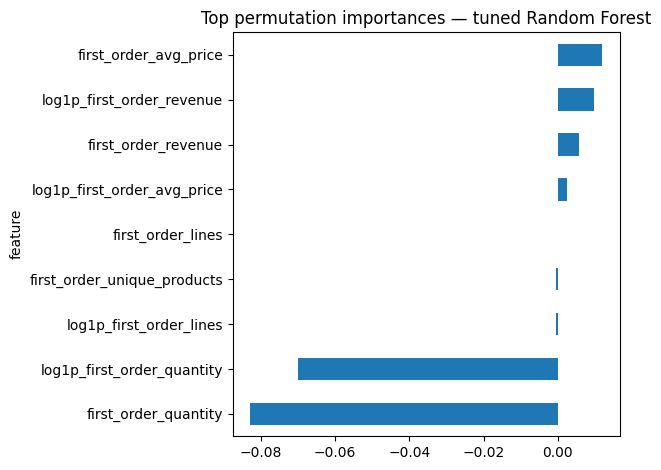

In [16]:
ax = importance.head(10).plot.barh(x='feature', y='importance_mean', legend=False)
ax.set_title('Top permutation importances — tuned Random Forest')
ax.invert_yaxis()
plt.tight_layout()

## 5. Business KPI simulation

Illustrative scenario: a retention campaign is sent to the highest-probability customers. The simulation estimates incremental revenue from a configurable conversion uplift and average repeat-order value. These are scenario assumptions, not causal estimates.

In [17]:
test_out = X_test.copy()
test_out['actual_repeat'] = y_test.values
test_out['p_repeat'] = rf_search.best_estimator_.predict_proba(X_test)[:,1]

CAMPAIGN_RATE = 0.20
CONVERSION_UPLIFT = 0.05
AVG_REPEAT_ORDER_VALUE = float(dataset.loc[dataset.repeat_customer.eq(1), 'first_order_revenue'].mean())
N_TARGETED = max(1, int(len(test_out) * CAMPAIGN_RATE))
top = test_out.nlargest(N_TARGETED, 'p_repeat')
expected_incremental_revenue = N_TARGETED * CONVERSION_UPLIFT * AVG_REPEAT_ORDER_VALUE
baseline_repeat_rate = float(y_test.mean())
targeted_observed_repeat_rate = float(top.actual_repeat.mean())

kpi = pd.Series({
    'customers_in_test': len(test_out),
    'customers_targeted': N_TARGETED,
    'baseline_repeat_rate': baseline_repeat_rate,
    'targeted_observed_repeat_rate': targeted_observed_repeat_rate,
    'avg_repeat_order_value_assumption': AVG_REPEAT_ORDER_VALUE,
    'assumed_conversion_uplift': CONVERSION_UPLIFT,
    'scenario_incremental_revenue': expected_incremental_revenue,
})
kpi

customers_in_test                    66.000000
customers_targeted                   13.000000
baseline_repeat_rate                  0.090909
targeted_observed_repeat_rate         0.153846
avg_repeat_order_value_assumption    28.522000
assumed_conversion_uplift             0.050000
scenario_incremental_revenue         18.539300
dtype: float64

## 6. Final fit and artifact

After model selection, the tuned estimator is refit on the training split (already performed by `GridSearchCV`) and saved under `models/`. Member 6 can load the `.joblib` artifact for deployment and use the JSON metadata for model/version information.

In [18]:
model_path, meta_path = save_artifact(
    rf_search.best_estimator_, DEFAULT_FEATURES, rf_metrics,
    output_dir=ROOT/'models', name='classical_repeat_purchase_rf_v1'
)
print(model_path)
print(meta_path)

E:\projects\Enterprise-AI-Data-Analyst-Member3-fixed\Enterprise-AI-Data-Analyst-main\models\classical_repeat_purchase_rf_v1.joblib
E:\projects\Enterprise-AI-Data-Analyst-Member3-fixed\Enterprise-AI-Data-Analyst-main\models\classical_repeat_purchase_rf_v1.json
